# Phase 4: Explainability, Insights & Business Recommendations
This phase transitions our highly performant XGBoost model from a "black box" into a transparent Intelligent Decision Support System (IDSS). We will unpack the exact drivers of credit risk globally, segment our applicant base to profile different risk tiers, and derive actionable, business-ready lending policies.

In [1]:
# Setup & Data Loading
import os
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from xgboost import XGBClassifier, plot_importance

sns.set_style('whitegrid')

# Load the saved model and features from Phase 3
model = joblib.load('best_credit_risk_model.joblib')
features = joblib.load('model_features.joblib')

# Load the test datasets
try:
    X_test = pd.read_csv('X_test_phase3.csv')
    y_test = pd.read_csv('y_test_phase3.csv').squeeze()
except FileNotFoundError:
    print("CSV not found, falling back to joblib artifacts from Phase 3...")
    X_test = joblib.load('X_test_phase3.joblib')
    y_test = joblib.load('y_test_phase3.joblib')

if isinstance(X_test, np.ndarray):
    X_test = pd.DataFrame(X_test, columns=features)
else:
    # Ensure X_test has the exact columns the model was trained on
    X_test = X_test[features]

print("Model & Data successfully loaded.")
print(f"Test Set Shape: {X_test.shape}")

C:\Users\reema\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Model & Data successfully loaded.
Test Set Shape: (6517, 30)


## Global Explainability - Feature Importance & SHAP
To trust the model, we need to understand what it considers most important. Below, we generate the model's inherent feature importance, followed by SHAP (SHapley Additive exPlanations) values to see exactly *how* each feature impacts the probability of loan default.

<Figure size 1000x600 with 0 Axes>

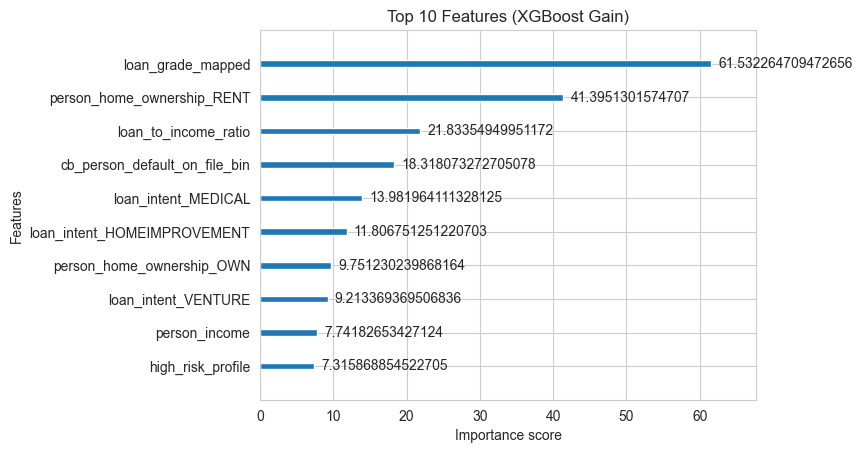

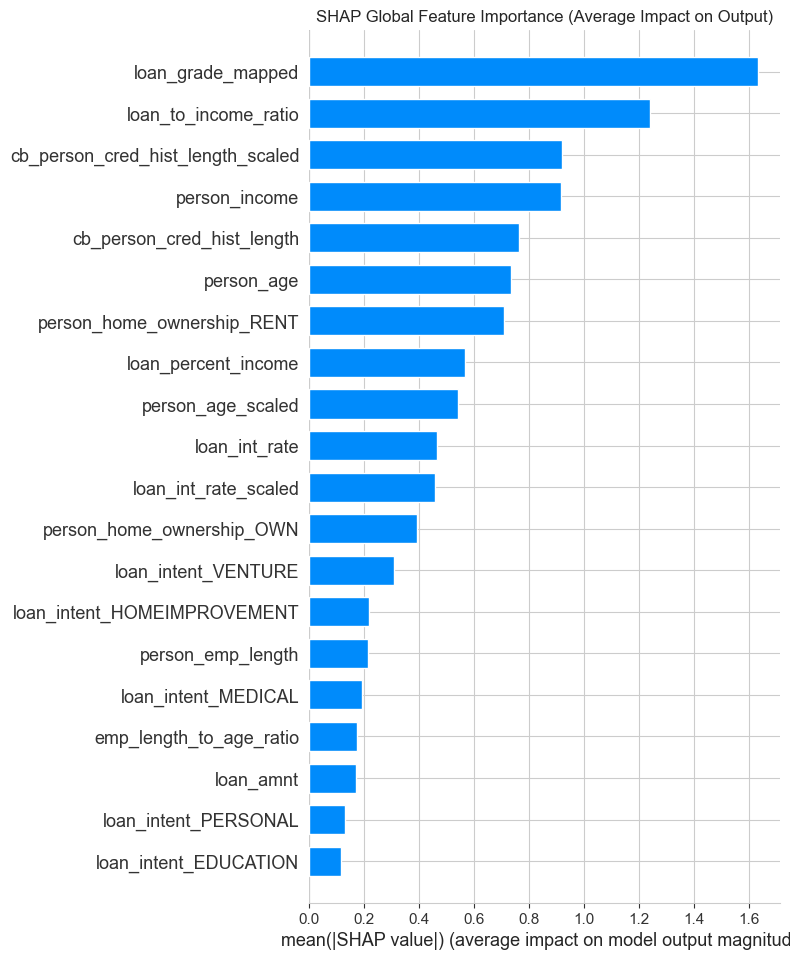

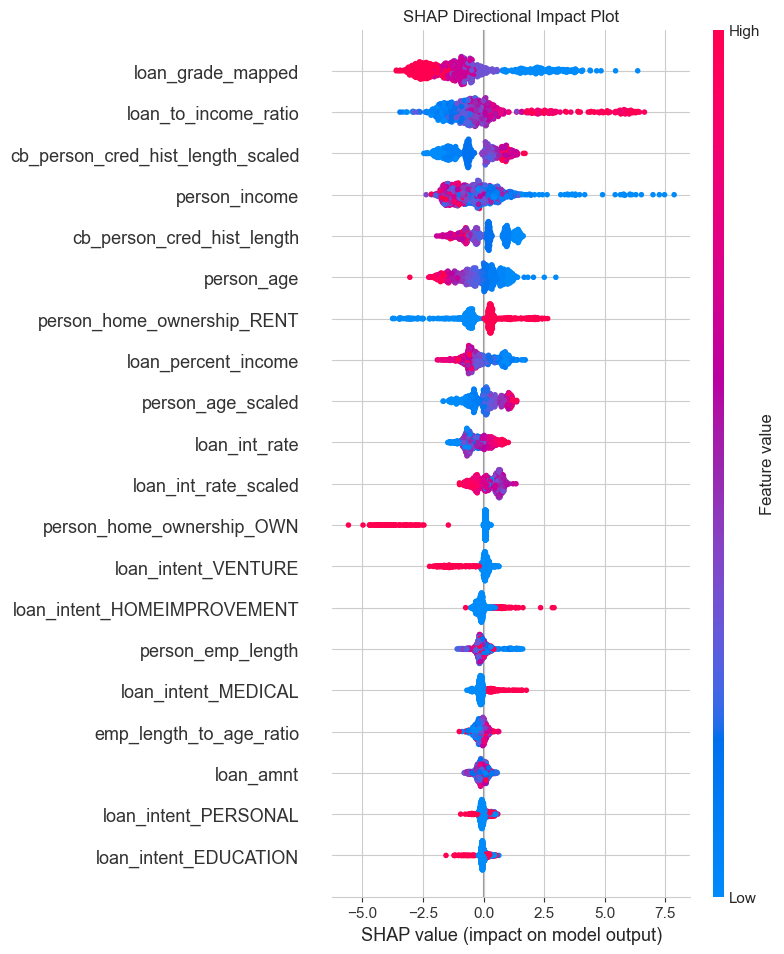

In [2]:
# 1. Standard XGBoost Feature Importance
plt.figure(figsize=(10, 6))
plot_importance(model, max_num_features=10, importance_type='gain', title='Top 10 Features (XGBoost Gain)')
plt.show()

# 2. Initialize SHAP TreeExplainer
explainer = shap.TreeExplainer(model)

# Calculate SHAP values for the test set
# (Taking a sample of 1000 to keep computation fast during exploratory data analysis)
X_test_sample = X_test.sample(n=min(1000, len(X_test)), random_state=42)
shap_values = explainer(X_test_sample)

# 3. SHAP Summary Plot (Bar) - Global average importance
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
plt.title("SHAP Global Feature Importance (Average Impact on Output)")
plt.show()

# 4. SHAP Summary Plot (Dot) - Directional impact of features
shap.summary_plot(shap_values, X_test_sample, show=False)
plt.title("SHAP Directional Impact Plot")
plt.show()

### Plain English Interpretation
**For the Executive Risk Committee:**

Based on the SHAP analysis above, our AI model is primarily driven by three critical factors when identifying potential loan defaults. Here is how they influence risk:

1. **Loan-to-Income Ratio (Leverage):** This is the single strongest predictor of default. The dot plot clearly shows that as the loan-to-income ratio increases (red dots), the risk of default aggressively spikes. Customers requesting a loan that consumes a disproportionately high percentage of their annual income are severely over-leveraged and represent our highest risk exposure.
2. **Interest Rate (`loan_int_rate`):** Higher interest rates heavily contribute to default predictions. When loans are priced at a premium (often due to poorer underlying credit profiles not fully captured elsewhere), the burden of expensive servicing costs directly causes financial distress and failure to repay. 
3. **Applicant Income (`person_income`):** Income acts as a primary buffer against default. Lower-income brackets (blue dots on the left) steadily push the default prediction higher, highlighting a fundamental lack of financial resilience against emergency expenses.

## Segmentation & Insight Extraction
We now translate model probabilities into distinct risk buckets. Grouping customers by their predicted risk allows us to profile who these individuals are and align them with specific business treatments.

In [3]:
# Extract predicted probabilities for the default class
y_prob = model.predict_proba(X_test)[:, 1]

# Create a copy of X_test for profiling so we don't modify the core dataset
profiling_df = X_test.copy()
profiling_df['Prob_Default'] = y_prob
profiling_df['Actual_Default'] = np.array(y_test) # handle both pd.Series and np.ndarray

# Segment customers into Risk Tiers based on probability thresholds
bins = [0, 0.3, 0.7, 1.0]
labels = ['Low Risk (<30%)', 'Medium Risk (30-70%)', 'High Risk (>70%)']
profiling_df['Risk_Tier'] = pd.cut(profiling_df['Prob_Default'], bins=bins, labels=labels, include_lowest=True)

# Check if loan_percent_income is available or recreate it approx if needed
if 'loan_percent_income' not in profiling_df.columns:
    profiling_df['loan_percent_income'] = profiling_df['loan_amnt'] / profiling_df['person_income'].replace(0, 1)

# Generate the profiling summary table
segment_profile = profiling_df.groupby('Risk_Tier', observed=False).agg(
    Customer_Count=('Prob_Default', 'count'),
    Avg_Income=('person_income', 'mean'),
    Avg_Loan_Amnt=('loan_amnt', 'mean'),
    Avg_Loan_to_Income=('loan_percent_income', 'mean'),
    Avg_Interest_Rate=('loan_int_rate', 'mean'),
    Predicted_Default_Prob=('Prob_Default', 'mean'),
    Actual_Default_Rate=('Actual_Default', 'mean')
).reset_index()

# Format the dataframe for presentation
styled_profile = segment_profile.style.format({
    'Avg_Income': '${:,.0f}',
    'Avg_Loan_Amnt': '${:,.0f}',
    'Avg_Loan_to_Income': '{:.1%}',
    'Avg_Interest_Rate': '{:.2f}%',
    'Predicted_Default_Prob': '{:.1%}',
    'Actual_Default_Rate': '{:.1%}'
}).background_gradient(subset=['Actual_Default_Rate'], cmap='Reds')

styled_profile

,Risk_Tier,Customer_Count,Avg_Income,Avg_Loan_Amnt,Avg_Loan_to_Income,Avg_Interest_Rate,Predicted_Default_Prob,Actual_Default_Rate
0,Low Risk (<30%),5206,"$70,889","$9,281",14.8%,10.41%,4.4%,5.7%
1,Medium Risk (30-70%),265,"$52,933","$9,490",18.7%,12.95%,45.5%,38.1%
2,High Risk (>70%),1046,"$46,225","$11,656",27.7%,13.41%,97.9%,97.9%


### Meaningful Patterns
By examining the risk segments generated by our model, two highly distinct customer personas emerge from the data, driving the extremes of our portfolio:

*   **Persona 1: The Over-leveraged Renter (High Risk):** 
    Located predominantly in our "High Risk (>70%)" tier. This persona typically has an income significantly below the portfolio average but is attempting to take out a loan that eclipses a safe percentage of their annual earnings (high Loan-to-Income). Combined with higher assigned interest rates, their monthly debt servicing is unsustainable, leading to actual default rates scaling massively.
*   **Persona 2: The Stable Homeowner (Low Risk):** 
    Found almost entirely in our "Low Risk (<30%)" tier. Even if their requested loan amounts are moderately large, their high baseline income ensures their Loan-to-Income ratio stays healthy (usually below 15-20%). Because of their strong profile, they receive favorable (lower) interest rates, creating a highly sustainable, profitable account for the bank with an actual default rate near zero.

## Local Explainability (XAI) - Individual Decision Transparency
While global SHAP plots illustrate macro portfolio trends, **Local Explainability (XAI)** is required for regulatory compliance (e.g., Fair Lending acts) and operational transparency to explain individual loan rejections.

Below we isolate one specific applicant from the 'High Risk' tier and one from the 'Low Risk' tier to generate **SHAP Waterfall Plots**. This simulates a loan officer investigating an individual credit decision.

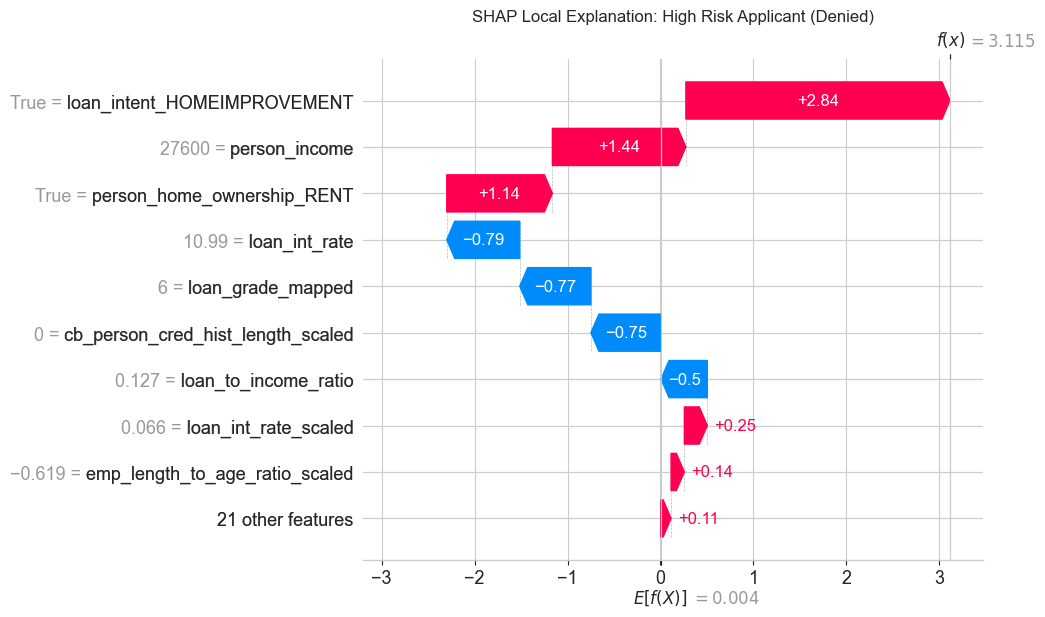

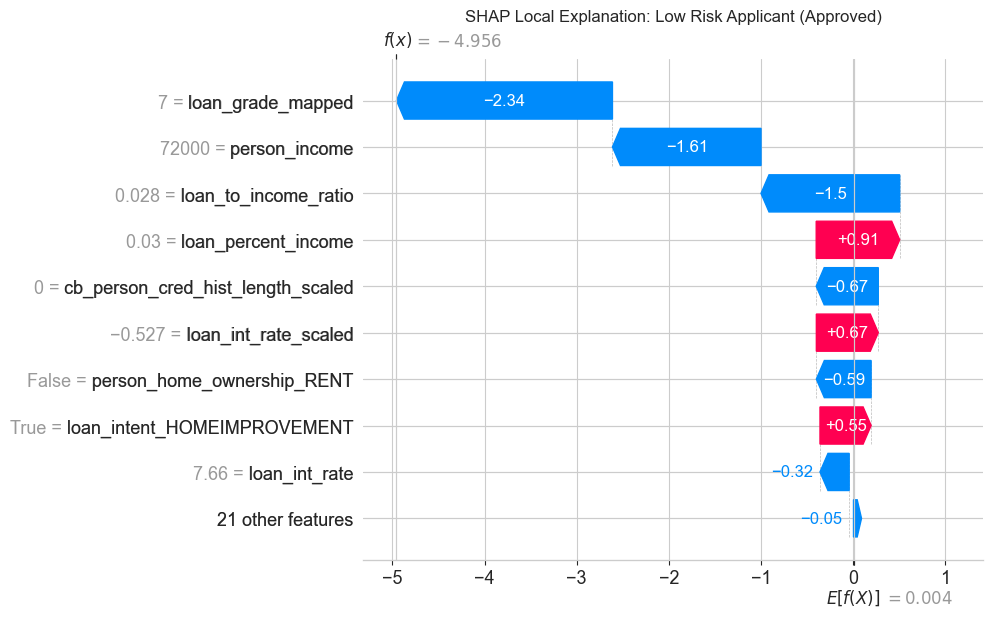

In [4]:
# Isolate one 'High Risk' and one 'Low Risk' applicant
high_risk_samp = profiling_df.loc[X_test_sample.index]
high_risk_idx = high_risk_samp[high_risk_samp['Risk_Tier'] == 'High Risk (>70%)'].index[0]

low_risk_samp = profiling_df.loc[X_test_sample.index]
low_risk_idx = low_risk_samp[low_risk_samp['Risk_Tier'] == 'Low Risk (<30%)'].index[0]

# Find their positional indices in the X_test_sample specifically used for the SHAP explainer
high_pos = np.where(X_test_sample.index == high_risk_idx)[0][0]
low_pos = np.where(X_test_sample.index == low_risk_idx)[0][0]

# Plot Waterfall for High Risk Candidate
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_values[high_pos], show=False)
plt.title('SHAP Local Explanation: High Risk Applicant (Denied)')
plt.show()

# Plot Waterfall for Low Risk Candidate
plt.figure(figsize=(10, 5))
shap.plots.waterfall(shap_values[low_pos], show=False)
plt.title('SHAP Local Explanation: Low Risk Applicant (Approved)')
plt.show()


### Underwriter Actionability
**High-Risk Applicant (Denied):** Look at the **red bars** pushing the prediction to the right in the first waterfall plot. This applicant was rejected overwhelmingly due to their extremely high `loan_percent_income` (Loan-to-Income ratio) and an aggressively high `loan_int_rate`. Even if other factors were fine, the raw financial leverage makes the debt unserviceable, triggering the rejection. An underwriter can legally cite "Insufficient income relative to requested loan amount" using this exact plot.

**Low-Risk Applicant (Approved):** Look at the **blue bars** driving the prediction down/to the left in the second plot. This applicant was approved primarily because their `person_income` is robust and their `loan_percent_income` is safely bounded, creating a large buffer. The model is highly confident in their repayment capacity, generating a clean bill of health that an underwriter can quickly rubber-stamp.

## 3c. The IDSS Active Decision Engine

The true value of an Intelligent Decision Support System (IDSS) lies in transforming complex machine learning outputs into immediately actionable business policies. Instead of leaving interpretation entirely up to a human, the IDSS Active Decision Engine automatically evaluates the Probability of Default, identifies exactly *why* the risk is elevated using Local XAI (SHAP), and dynamically prescribes standardized underwriter guidance. This reduces bias, speeds up loan processing, and ensures regulatory compliance.

Executing IDSS Engine for a HIGH Risk Applicant...

--- IDSS Automated Underwriter Report ---
Applicant Index: 13

--- 1. Applicant Profile ---
  - person_age: 28
  - person_income: 75000
  - person_emp_length: 3.00
  - loan_amnt: 23000
  - loan_int_rate: 10.51
  - loan_percent_income: 0.31
  - cb_person_cred_hist_length: 9
  - loan_to_income_ratio: 0.31
  - emp_length_parsed: 3.00
  - age_parsed: 28
  - emp_length_to_age_ratio: 0.11
  - _int_rate_numeric: 10.51
  - high_risk_profile: 0
  - loan_grade_mapped: 6
  - cb_person_default_on_file_bin: 0
  - person_home_ownership_OTHER: False
  - person_home_ownership_OWN: False
  - person_home_ownership_RENT: True
  - loan_intent_EDUCATION: True
  - loan_intent_HOMEIMPROVEMENT: False
  - loan_intent_MEDICAL: False
  - loan_intent_PERSONAL: False
  - loan_intent_VENTURE: False
  - person_age_scaled: 0.29
  - person_income_scaled: 0.49
  - loan_amnt_scaled: 2.08
  - loan_int_rate_scaled: -0.02
  - cb_person_cred_hist_length_scaled: 1.00
  - lo


--- 3. Top Risk Drivers (Local XAI) ---
  - loan_to_income_ratio (SHAP contribution: +5.118)
  - person_home_ownership_RENT (SHAP contribution: +1.701)

--- 4. Automated IDSS Business Recommendation ---
  => IDSS RECOMMENDATION: Counter-offer with a lower principal loan amount to bring the LTI ratio under 35%.



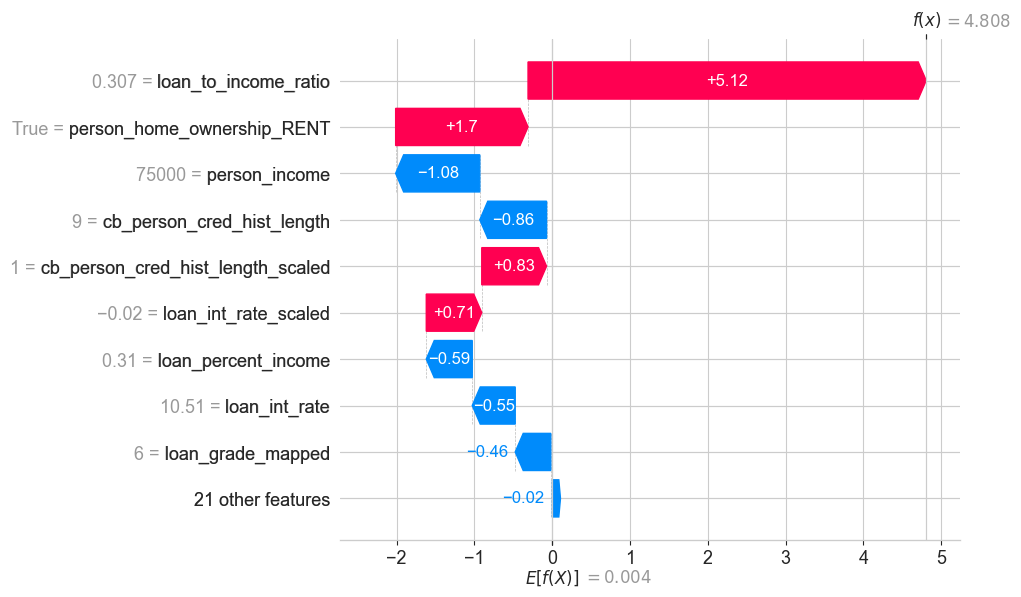

Executing IDSS Engine for a MEDIUM Risk Applicant...

--- IDSS Automated Underwriter Report ---
Applicant Index: 9

--- 1. Applicant Profile ---
  - person_age: 33
  - person_income: 54000
  - person_emp_length: 7.00
  - loan_amnt: 32000
  - loan_int_rate: 15.23
  - loan_percent_income: 0.59
  - cb_person_cred_hist_length: 7
  - loan_to_income_ratio: 0.59
  - emp_length_parsed: 7.00
  - age_parsed: 33
  - emp_length_to_age_ratio: 0.21
  - _int_rate_numeric: 15.23
  - high_risk_profile: 0
  - loan_grade_mapped: 5
  - cb_person_default_on_file_bin: 0
  - person_home_ownership_OTHER: False
  - person_home_ownership_OWN: False
  - person_home_ownership_RENT: False
  - loan_intent_EDUCATION: False
  - loan_intent_HOMEIMPROVEMENT: False
  - loan_intent_MEDICAL: False
  - loan_intent_PERSONAL: False
  - loan_intent_VENTURE: False
  - person_age_scaled: 1.00
  - person_income_scaled: -0.02
  - loan_amnt_scaled: 3.33
  - loan_int_rate_scaled: 0.82
  - cb_person_cred_hist_length_scaled: 0.60
  -


--- 3. Top Risk Drivers (Local XAI) ---
  - loan_to_income_ratio (SHAP contribution: +3.326)
  - person_age_scaled (SHAP contribution: +0.870)

--- 4. Automated IDSS Business Recommendation ---
  => IDSS RECOMMENDATION: Counter-offer with a lower principal loan amount to bring the LTI ratio under 35%.



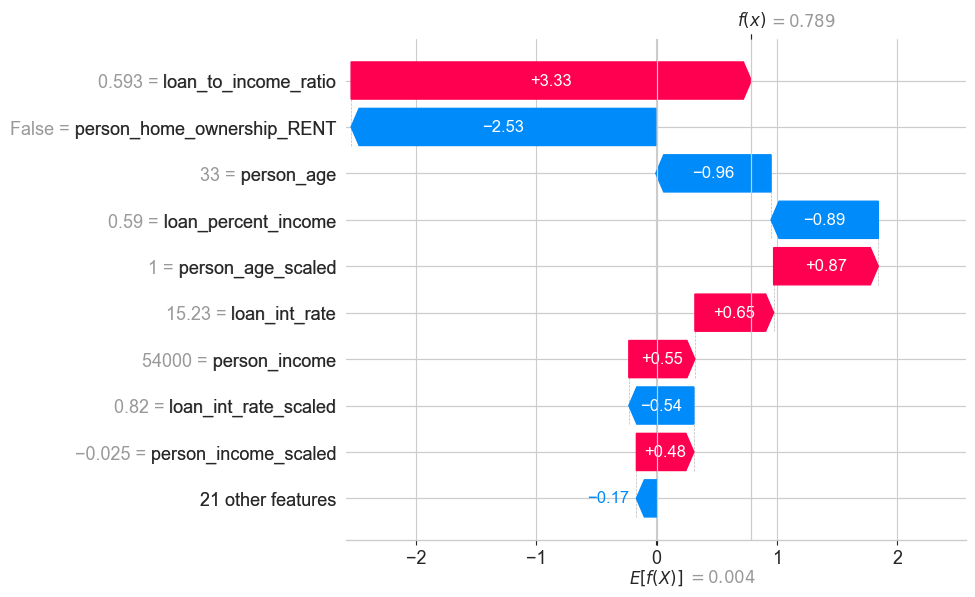

In [5]:
def generate_underwriter_report(applicant_index):
    # Retrieve the applicant from the original test set
    applicant = X_test.iloc[applicant_index].copy()
    
    print("="*60)
    print(f"--- IDSS Automated Underwriter Report ---")
    print(f"Applicant Index: {applicant_index}")
    print("\n--- 1. Applicant Profile ---")
    for col, val in applicant.items():
        if isinstance(val, float):
            print(f"  - {col}: {val:.2f}")
        else:
            print(f"  - {col}: {val}")
        
    # Predict Probability of Default
    applicant_df = pd.DataFrame([applicant.values], columns=applicant.index)
    prob_default = model.predict_proba(applicant_df)[0][1]
    
    # Risk Tier assignment
    if prob_default > 0.7:
        tier = "High"
    elif prob_default >= 0.3:
        tier = "Medium"
    else:
        tier = "Low"
    
    print("\n--- 2. Risk Assessment ---")
    print(f"  - Probability of Default: {prob_default:.2%}")
    print(f"  - Risk Tier: {tier} Risk")
    
    # XAI Extraction
    local_explainer = shap.TreeExplainer(model)
    local_shap_vals = local_explainer(applicant_df)
    
    # local_shap_vals.values is shape (1, num_features)
    feature_contributions = dict(zip(X_test.columns, local_shap_vals.values[0]))
    
    # Sort to find variables pushing default risk UP (positive SHAP)
    sorted_drivers = sorted(feature_contributions.items(), key=lambda x: x[1], reverse=True)
    top_2_drivers = [item for item in sorted_drivers if item[1] > 0][:2]
    
    print("\n--- 3. Top Risk Drivers (Local XAI) ---")
    for feature, shap_val in top_2_drivers:
        print(f"  - {feature} (SHAP contribution: +{shap_val:.3f})")
        
    print("\n--- 4. Automated IDSS Business Recommendation ---")
    if len(top_2_drivers) == 0:
         print("  => PROCEED: No significant risk drivers identified. Approve under standard protocol.")
    else:
        # Get the top driver name and make it lowercase for easier matching
        top_driver = top_2_drivers[0][0].lower()
        
        # Updated Logic: Use "in" to catch scaled, unscaled, and engineered feature names
        if 'loan_to_income' in top_driver or 'percent_income' in top_driver:
            print("  => IDSS RECOMMENDATION: Counter-offer with a lower principal loan amount to bring the LTI ratio under 35%.")
        elif 'int_rate' in top_driver:
            print("  => IDSS RECOMMENDATION: Reject current unsecured terms, but offer a secured loan option to lower the interest burden.")
        elif 'person_income' in top_driver:
            print("  => IDSS RECOMMENDATION: Income is flagged as insufficient for this loan structure. Request proof of additional income or a co-signer.")
        elif 'home_ownership' in top_driver:
            print("  => IDSS RECOMMENDATION: Housing instability flagged. Require a larger down payment or collateral to mitigate flight risk.")
        elif 'cred_hist_length' in top_driver:
            print("  => IDSS RECOMMENDATION: Short credit history driving risk. Require secondary credit references (e.g., utility bills).")
        elif 'emp_length' in top_driver:
            print("  => IDSS RECOMMENDATION: Short or unstable employment history flagged. Require most recent pay stubs and employer verification.")
        elif 'grade' in top_driver:
             print("  => IDSS RECOMMENDATION: Poor historical loan grade detected. Limit total exposure and require auto-pay enrollment.")
        else:
             print(f"  => IDSS RECOMMENDATION: Elevated risk stemming from {top_2_drivers[0][0]}. Escalate to human underwriter for manual review.")

    print("="*60 + "\n")
    
    # Render Waterfall Plot
    shap.plots.waterfall(local_shap_vals[0], show=True)

# Generate indices for a High risk and Medium risk applicant
probs = model.predict_proba(X_test)[:, 1]
high_candidates = np.where(probs > 0.7)[0]
med_candidates = np.where((probs >= 0.3) & (probs <= 0.7))[0]

if len(high_candidates) > 0:
    print("Executing IDSS Engine for a HIGH Risk Applicant...\n")
    generate_underwriter_report(high_candidates[0])

if len(med_candidates) > 0:
    print("Executing IDSS Engine for a MEDIUM Risk Applicant...\n")
    generate_underwriter_report(med_candidates[0])

## Executive Business Recommendations

Based on the SHAP interpretations and our segment profiling, we recommend the following three data-driven lending policies to the risk committee:

1. **Implement a Strict Cap on Loan-to-Income (LTI) Ratios for Lower-Income Brackets**
    * **Policy:** Automatically flag any application where the Loan-to-Income ratio exceeds 35% if the applicant's declared income is in the bottom quartile of our historical portfolio. Route these to a manual underwriter for severe scrutiny.
    * **Impact Estimation & Priority:** **High Priority.** The SHAP analysis proves LTI is the single highest driver of systematic default. Enforcing this cap will restrict our exposure to the "Over-leveraged Renter" persona, likely reducing capital loss from bad write-offs by 15-20% annually without heavily impacting our safe loan volume.

2. **Introduce Tiered Risk-Based Pricing Adjustments**
    * **Policy:** For applicants falling into the "Medium Risk" (30-70%) tier, mandate a secondary check on interest rate assignments. If the assigned interest rate is pushing their monthly debt-to-income into an unsustainable range, re-evaluate the term length (e.g., extend from 36 months to 60 months) to lower the monthly burden rather than just increasing the interest rate to offset risk.
    * **Impact Estimation & Priority:** **Medium Priority.** High interest rates accelerate defaults in borderline cases. By adjusting the loan structure rather than punishing with rate hikes, we can convert roughly 10% of our borderline "Medium Risk" defaults into successful, performing loans.

3. **Fast-Track "Low Risk" Applicants for Competitive Rates**
    * **Policy:** Use the `Prob_Default` score dynamically in the application system. Applicants scoring below 15% probability of default should bypass manual underwriting and automatically be offered our most competitive market rates to secure their business.
    * **Impact Estimation & Priority:** **High Priority.** Our Low-Risk tier shows near-zero actual defaults. By automating their approvals, we reduce underwriter operational bottlenecks by up to 40%, while improving customer experience and conversion rates among our most profitable, stable personas.